# EDA - Customer Churn

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from customer_churn.data.loader import load_data

RAW_PATH = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
TRAIN_PATH = Path("../data/interim/train.csv")

## 1. Quick audit (raw data)

Superficial checks on the raw dataset, done before any cleaning, to decide what `cleaning.py` actually needs to handle (wrong dtypes, duplicates, impossible values).

In [2]:
df_raw = load_data(RAW_PATH)
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df_raw.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df_raw.duplicated().sum()

np.int64(0)

## 2. EDA on train split

From here on, work on `data/interim/train.csv` (produced by `scripts/split_data.py`) instead of the full interim dataset - correct dtypes, no duplicates, no impossible values, missing values (e.g. `TotalCharges`) still visible as NaN. Only the train split is explored, to avoid making decisions informed by data that should stay unseen until final evaluation.

In [7]:
df = load_data(TRAIN_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  Paymen

### Target distribution (`Churn`)

In [8]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

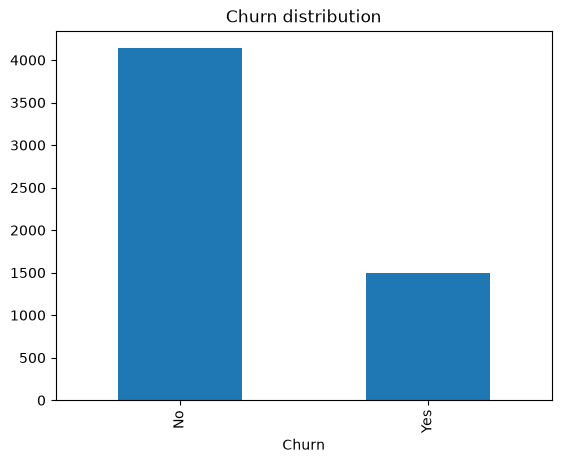

In [9]:
df["Churn"].value_counts().plot(kind="bar", title="Churn distribution")
plt.show()

### Numeric feature distributions

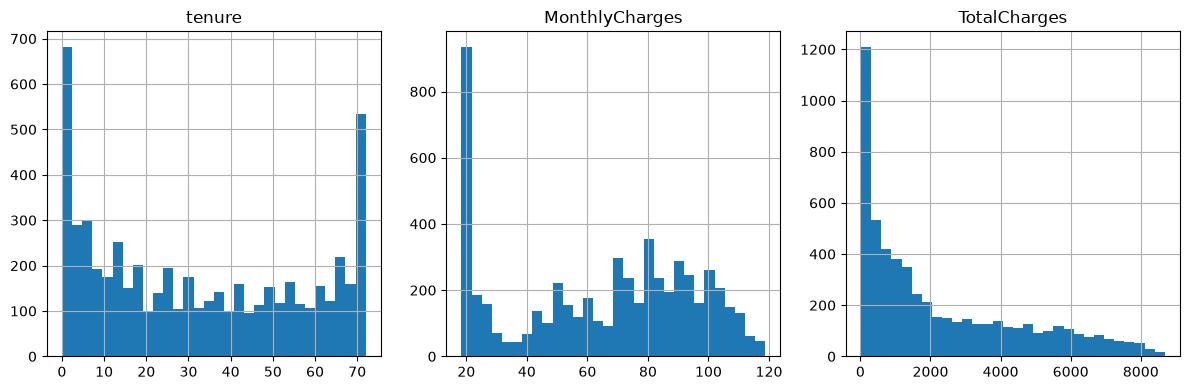

In [10]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols].hist(figsize=(12, 4), bins=30, layout=(1, 3))
plt.tight_layout()
plt.show()

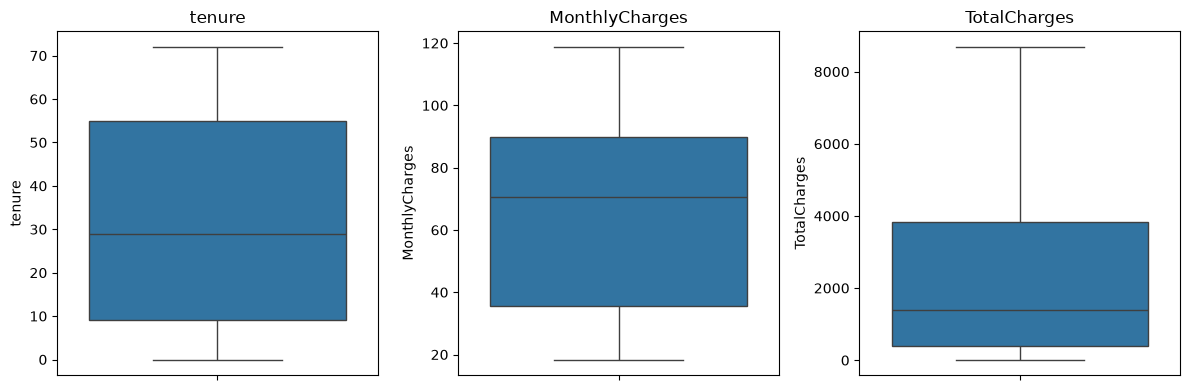

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Correlation between numeric features

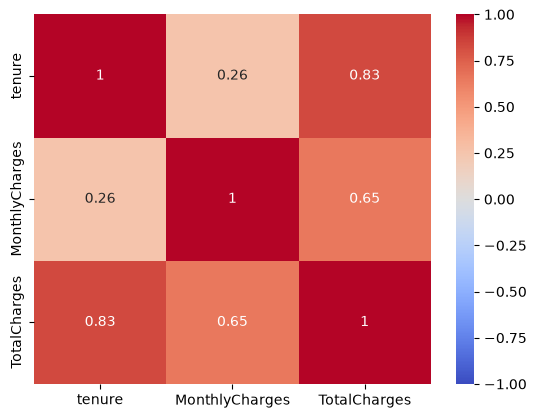

In [12]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

### Churn rate by categorical features

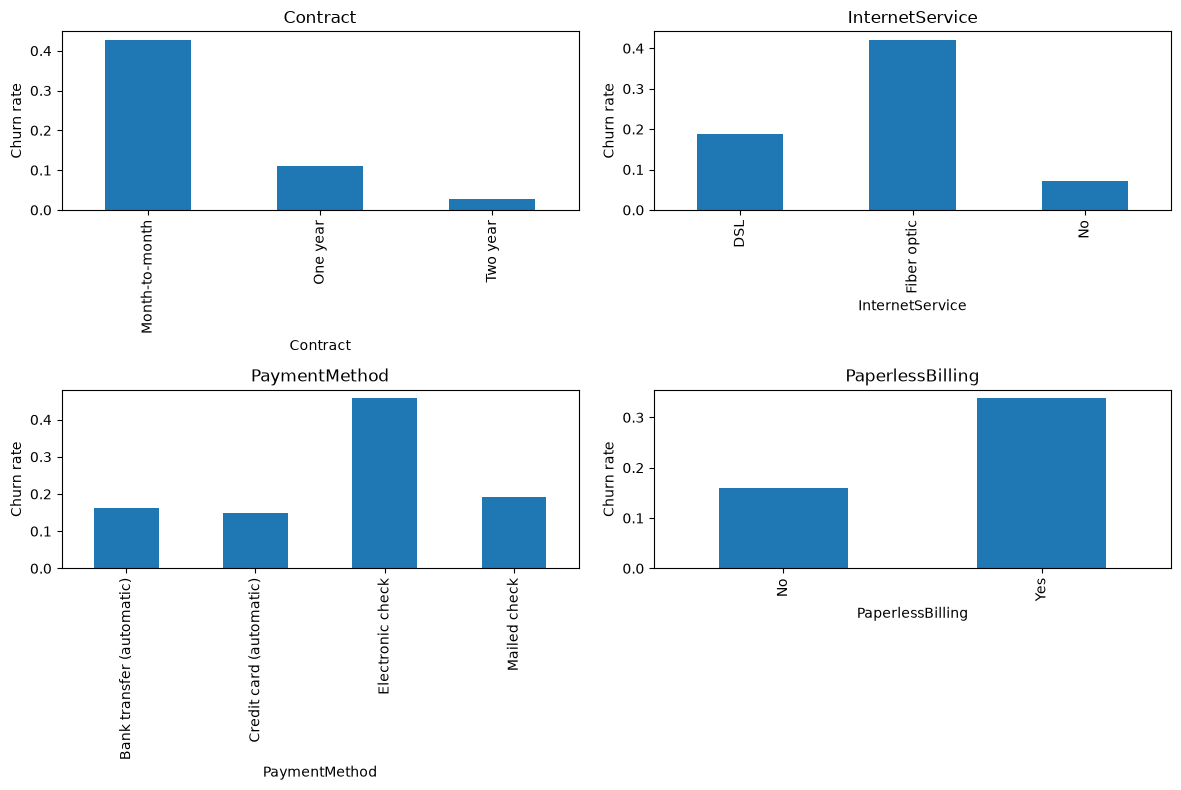

In [13]:
categorical_cols = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, categorical_cols):
    df.groupby(col)["Churn"].value_counts(normalize=True).unstack()["Yes"].plot(
        kind="bar", ax=ax, title=col
    )
    ax.set_ylabel("Churn rate")
plt.tight_layout()
plt.show()

### Missing `TotalCharges` pattern

Investigate why `TotalCharges` is NaN for some rows, to justify an imputation strategy later (in feature engineering, not here).

In [14]:
# tenure distribution among rows with TotalCharges missing
df.loc[df["TotalCharges"].isna(), "tenure"].value_counts()

tenure
0    8
Name: count, dtype: int64

In [15]:
# reverse check: is TotalCharges missing for every row with tenure == 0?
df.loc[df["tenure"] == 0, "TotalCharges"].isna().value_counts()

TotalCharges
True    8
Name: count, dtype: int64